# friant_uncertainty_viz.ipynb

Plot the MLR basin-SWE prediction with an uncertainty band derived from the ranked pillow
combinations, one panel per decade.

`ensemble_tidy_wy{YYYY}.csv` is long: one row per `(date, isImpute, elev_band, rank)`.
Rank 1 is the published prediction (identical to `prediction_mm_wy{YYYY}_combination.csv`,
modulo that the published file is `int()`-truncated). Ranks 2..N are the next-best pillow
combinations by cross-validated adjusted R2 -- they were already being computed inside
`identify_best_stations` and discarded; the spread across them is the uncertainty estimate.

Three things worth knowing before reading the figure:

1. **Do not pool the two imputation modes.** `drop NaNs` and `predict NaNs` search different
   candidate pools (`baseline_pils` vs `pils_removed`) against different training tables, and
   the impute mode scores partly against synthetic predictors. Select one; that is what
   `MODEL` does.
2. **Rank is not a stable entity across time.** The available pillows change, so rank 2 on one
   date can be a different combination than rank 2 on the next. That is why this plots a band
   and never a per-rank line.
3. **`ADJ_R2_TOL` matters.** In some elevation bands adjusted R2 falls >0.5 between rank 1 and
   rank 10, meaning the tail members are models the selection criterion already rejected.
   Including them widens the band without adding information. Set a tolerance to keep only
   members within that distance of rank 1.

## Inputs

In [5]:
VERSION   = 'v7_ens'          # output dir under FRIANT/, e.g. v6_pre, v7_ens
MODEL     = 'predict NaNs'    # 'drop NaNs' or 'predict NaNs'

ELEV_BAND = 'total'           # 'total' = basin mean; or '<7000' ... '>12000'
BAND      = 'p10_p90'         # 'p10_p90' | 'min_max' | 'sd'
N_RANKS   = 10                # use ranks 1..N_RANKS
ADJ_R2_TOL = None             # e.g. 0.05 -> drop members >0.05 below rank 1's adj_r2. None = keep all
SHOW_ASO  = True              # mark ASO flight dates (where observed truth exists)

BASIN     = 'FRIANT'
SEASONAL  = 'season'
SAVE_FIG  = None              # e.g. 'friant_uncertainty_v7_ens_predictNaNs.png'

## Load

In [6]:
import re
from pathlib import Path

import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

ROOT = Path(f'/home/rossamower/work/aso/data/mlr_prediction/{BASIN}')
SRC  = ROOT / VERSION / SEASONAL

files = sorted(SRC.glob('ensemble_tidy_wy*.csv'))
if not files:
    raise SystemExit(f'no ensemble_tidy_wy*.csv under {SRC}')

frames = []
for f in files:
    wy = int(re.search(r'wy(\d{4})', f.name).group(1))
    df = pd.read_csv(f)
    df['water_year'] = wy
    frames.append(df)
e = pd.concat(frames, ignore_index=True)
e['date'] = pd.to_datetime(e['date'])

years = sorted(e.water_year.unique())
missing = [y for y in range(min(years), max(years) + 1) if y not in years]
print(f'loaded {len(files)} water years: {min(years)}-{max(years)}   rows={len(e):,}')
if missing:
    print(f'MISSING (sweep may still be running): {missing}')
print('columns:', list(e.columns))

loaded 46 water years: 1980-2025   rows=2,568,115
columns: ['modelID', 'elev_band', 'isImpute', 'date', 'rank', 'adj_r2', 'pillows', 'pred_mm', 'pred_acreFt', 'n_QA', 'n_baseline', 'pillows_QA', 'water_year']


## Aggregate to one band per date

`isImpute=False` is `drop NaNs`; `isImpute=True` is `predict NaNs`. Rank 1 is taken directly
rather than joined from `prediction_mm_*.csv`, so the centre line and the band come from the
same full-precision source -- mixing a truncated centre with an untruncated band can put the
line marginally outside its own envelope.

In [7]:
IMPUTE_FLAG = {'drop NaNs': False, 'predict NaNs': True}[MODEL]

d = e[(e.isImpute == IMPUTE_FLAG) & (e.elev_band == ELEV_BAND)].copy()
d = d[d['rank'] <= N_RANKS]
d = d.dropna(subset=['pred_mm'])

if ADJ_R2_TOL is not None:
    top = d.groupby('date')['adj_r2'].transform('max')
    keep = d['adj_r2'] >= (top - ADJ_R2_TOL)
    print(f'ADJ_R2_TOL={ADJ_R2_TOL}: keeping {keep.sum():,}/{len(d):,} members '
          f'({100*keep.mean():.1f}%)')
    d = d[keep]

g = d.groupby('date')['pred_mm']
agg = pd.DataFrame({
    'rank1': d[d['rank'] == 1].set_index('date')['pred_mm'],
    'mean' : g.mean(),
    'sd'   : g.std(),
    'lo_mm': g.min(),
    'hi_mm': g.max(),
    'p10'  : g.quantile(0.10),
    'p90'  : g.quantile(0.90),
    'n'    : g.size(),
}).sort_index()

# availability, recorded per date by the runner (not inferred -- inferring it from the
# ensemble output once produced a spurious result).
if 'n_QA' in d.columns:
    agg['n_QA'] = d.groupby('date')['n_QA'].first()
    agg['n_baseline'] = d.groupby('date')['n_baseline'].first()

if BAND == 'p10_p90':
    agg['lo'], agg['hi'], band_label = agg.p10, agg.p90, 'p10-p90 of top-%d' % N_RANKS
elif BAND == 'min_max':
    agg['lo'], agg['hi'], band_label = agg.lo_mm, agg.hi_mm, 'min-max of top-%d' % N_RANKS
elif BAND == 'sd':
    agg['lo'], agg['hi'] = agg.rank1 - agg.sd, agg.rank1 + agg.sd
    band_label = 'rank1 +/- 1 sd'
else:
    raise ValueError(BAND)

print(f'{len(agg):,} dates  |  band = {band_label}')
agg.head()

16,756 dates  |  band = p10-p90 of top-10


,rank1,mean,sd,lo_mm,hi_mm,p10,p90,n,n_QA,n_baseline,lo,hi
date,,,,,,,,,,,,
1979-10-02,0.0,0.0,0.0,0.0,0.0,0.0,0.0,7,5,3,0.0,0.0
1979-10-03,0.0,0.0,0.0,0.0,0.0,0.0,0.0,7,5,3,0.0,0.0
1979-10-04,0.0,0.0,0.0,0.0,0.0,0.0,0.0,7,5,3,0.0,0.0
1979-10-05,0.0,0.0,0.0,0.0,0.0,0.0,0.0,7,5,3,0.0,0.0
1979-10-06,0.0,0.0,0.0,0.0,0.0,0.0,0.0,7,5,3,0.0,0.0


## Figure -- one panel per decade

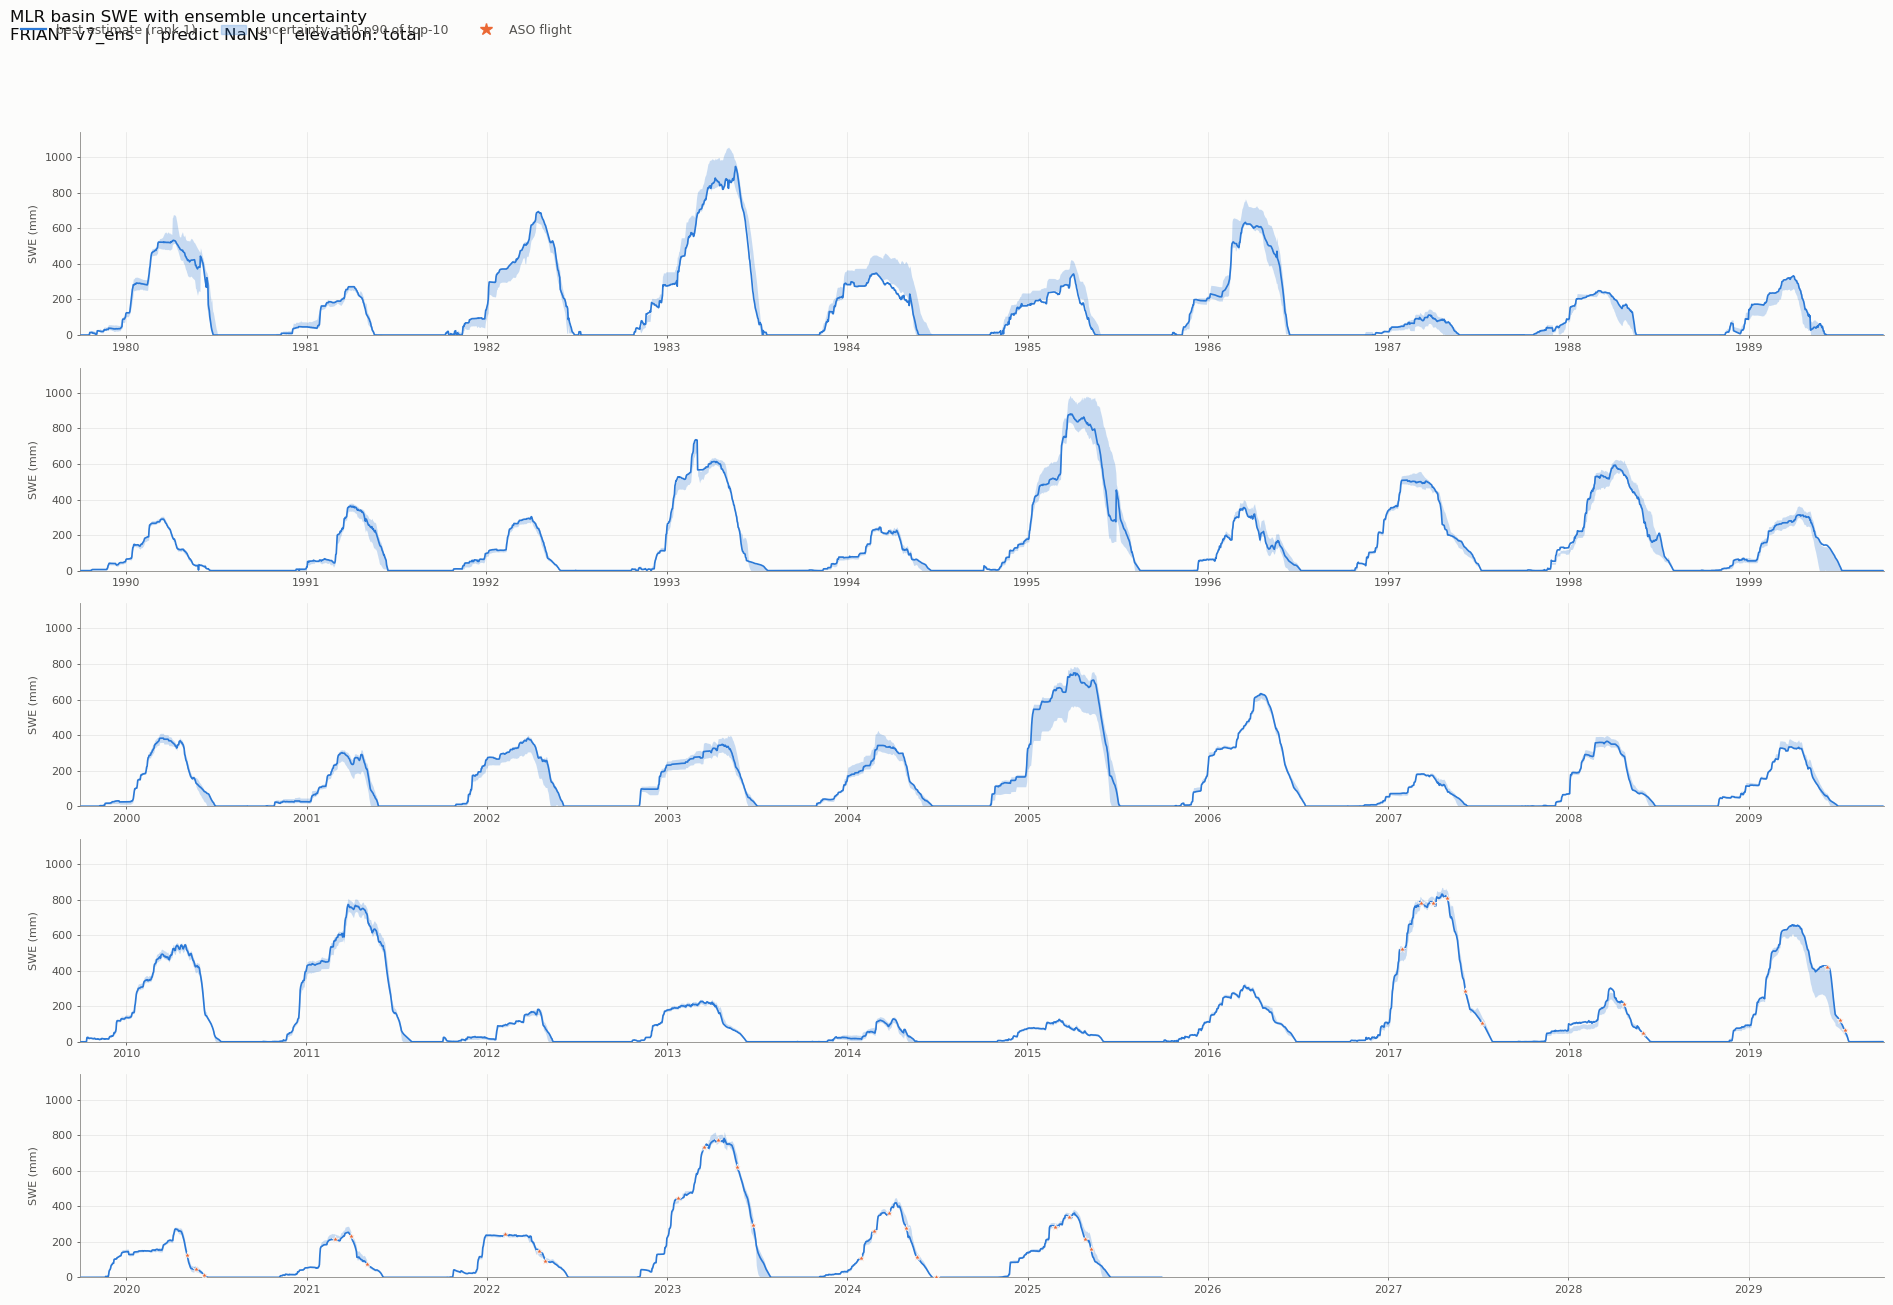

In [8]:
# Categorical palette slots 1-2 of the validated default set. One data series plus its band,
# so the band reuses the line's hue at low alpha (same entity, not a second category); the
# ASO markers get a distinct hue because they are a different kind of thing (observed truth).
C_LINE  = '#2a78d6'   # slot 1, blue
C_ASO   = '#eb6834'   # slot 2, orange
SURFACE = '#fcfcfb'
INK, INK2, MUTED = '#0b0b0b', '#52514e', '#8a8985'

aso_dates = []
if SHOW_ASO:
    try:
        ts = xr.open_dataset(f'/home/rossamower/work/aso/data/aso/{BASIN}/ASO_50M_SWE_TSERIES.nc')
        aso_dates = pd.DatetimeIndex(pd.to_datetime(ts.date.values)).normalize()
    except Exception as exc:
        print('ASO flight dates unavailable:', exc)

# Decade panels on WATER-year boundaries, not calendar years. A water year starts Oct 1 of
# the previous calendar year, so WY1980 begins 1979-10-01 -- taking the decade from the
# minimum *date* would put the first panel at 1970. Panel (a, b) spans WY a..b-1, i.e.
# Oct 1 of (a-1) through Oct 1 of (b-1).
wy_lo = (min(years) // 10) * 10
wy_hi = max(years)
edges = [y for y in range(wy_lo, wy_hi + 11, 10)]
panels = [(a, b) for a, b in zip(edges[:-1], edges[1:]) if a <= wy_hi]

fig, axes = plt.subplots(len(panels), 1, figsize=(19, 2.6 * len(panels)),
                         facecolor=SURFACE)
axes = np.atleast_1d(axes)
ymax = float(np.nanmax([agg.hi.max(), agg.rank1.max()])) * 1.08

for ax, (y0, y1) in zip(axes, panels):
    m = (agg.index >= f'{y0-1}-10-01') & (agg.index < f'{y1-1}-10-01')
    a = agg[m]

    ax.set_facecolor(SURFACE)
    for s in ('top', 'right'):
        ax.spines[s].set_visible(False)
    for s in ('left', 'bottom'):
        ax.spines[s].set_color(MUTED); ax.spines[s].set_linewidth(0.6)
    ax.grid(True, color=MUTED, alpha=0.20, linewidth=0.5)
    ax.set_axisbelow(True)
    ax.tick_params(colors=INK2, labelsize=8, length=2, width=0.6)

    if len(a):
        ax.fill_between(a.index, a.lo, a.hi, color=C_LINE, alpha=0.25, lw=0, zorder=2)
        ax.plot(a.index, a.rank1, color=C_LINE, lw=1.2, zorder=3, solid_capstyle='round')

    if len(aso_dates):
        f = aso_dates[(aso_dates >= f'{y0-1}-10-01') & (aso_dates < f'{y1-1}-10-01')]
        if len(f):
            yv = agg.rank1.reindex(f).values
            ax.scatter(f, yv, s=26, marker='*', color=C_ASO, zorder=4,
                       edgecolor=SURFACE, linewidth=0.5)

    ax.set_xlim(pd.Timestamp(f'{y0-1}-10-01'), pd.Timestamp(f'{y1-1}-10-01'))
    ax.set_ylim(0, ymax)
    ax.xaxis.set_major_locator(mdates.YearLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    ax.set_ylabel('SWE (mm)', fontsize=8, color=INK2)

handles = [
    plt.Line2D([], [], color=C_LINE, lw=1.6, label='best estimate (rank 1)'),
    plt.Rectangle((0, 0), 1, 1, color=C_LINE, alpha=0.25, label=f'uncertainty: {band_label}'),
]
if len(aso_dates):
    handles.append(plt.Line2D([], [], color=C_ASO, marker='*', lw=0, markersize=9,
                              label='ASO flight'))
fig.legend(handles=handles, loc='upper left', bbox_to_anchor=(0.006, 0.998),
           ncol=3, frameon=False, fontsize=9, labelcolor=INK2)

sub = f'{BASIN} {VERSION}  |  {MODEL}  |  elevation: {ELEV_BAND}'
if ADJ_R2_TOL is not None:
    sub += f'  |  adj-R2 within {ADJ_R2_TOL} of rank 1'
fig.suptitle(f'MLR basin SWE with ensemble uncertainty\n{sub}',
             x=0.006, ha='left', y=1.0, fontsize=12, color=INK)
fig.tight_layout(rect=[0.008, 0, 1, 0.955])

if SAVE_FIG:
    fig.savefig(SAVE_FIG, dpi=200, facecolor=SURFACE, bbox_inches='tight')
    print('wrote', SAVE_FIG)
plt.show()

## Figure -- Individual year comparison
lets now look at one year as an input provided by the user and compare the drop NaNs and predict NaNs rank one predictions and then shaded uncertainty 

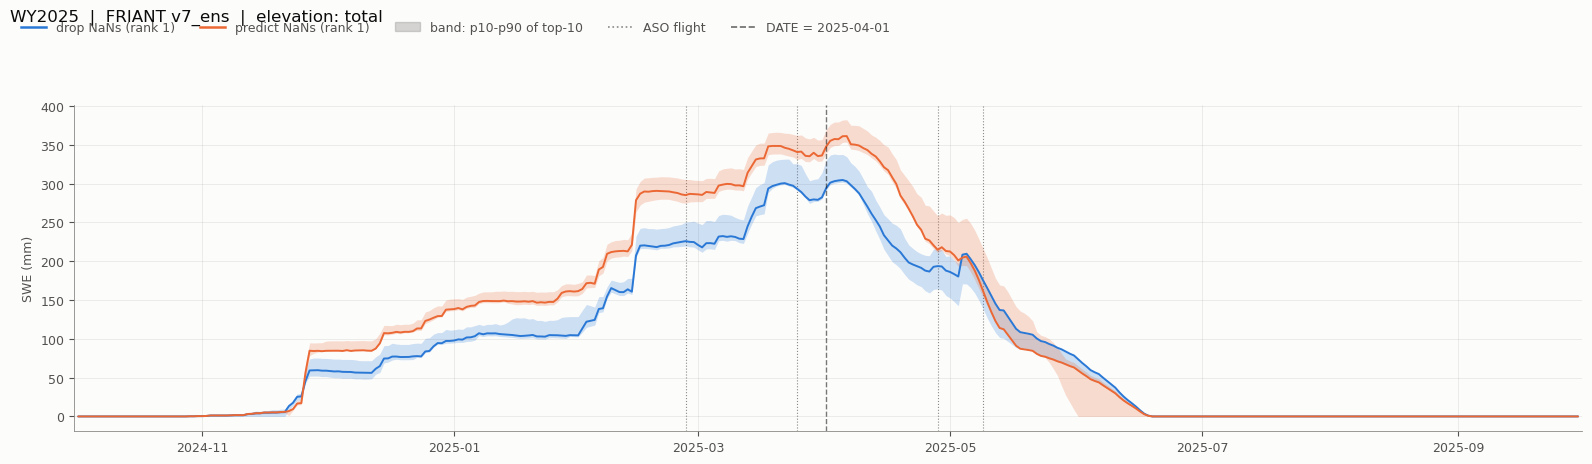

,mode,dates,peak_rank1_mm,peak_date,mean_sd_mm,mean_band_width_mm
0,drop NaNs,364,304.8,2025-04-05,7.9,15.3
1,predict NaNs,364,361.3,2025-04-06,7.0,15.9


In [9]:
# ---------------------------------------------------------------------------
# Inputs for this figure and the zoom figure below.
#
# These re-bind ELEV_BAND and MODEL from the top Inputs cell on purpose, so this section can
# be explored without touching the decade figure. Note the coupling: if you re-run the
# "Aggregate" and decade-figure cells AFTER running this one, they will use these values.
# ---------------------------------------------------------------------------
WATER_YEAR = 2025               # e.g. 2025
ELEV_BAND  = 'total'            # e.g. 'total', '<7000' ... '>12000'
MODEL      = 'predict NaNs'     # 'predict NaNs' | 'drop NaNs'
DATE       = '2025-04-01'       # used by the zoom figure below

MODE_FLAG = {'drop NaNs': False, 'predict NaNs': True}


def ensemble_band(mode, elev_band, water_year=None, n_ranks=N_RANKS, adj_r2_tol=ADJ_R2_TOL):
    """
    Collapse the ranked members to one row per date: rank-1 plus a spread.

    Deliberately reads `e` (the raw concat) rather than the `agg` frame built earlier, so
    this section is independent of whatever MODEL/ELEV_BAND were set to up there.
    Rank 1 is taken from the tidy file, not joined from prediction_mm_*.csv, because the
    published file is int()-truncated -- mixing a truncated centre with an untruncated band
    can put the line marginally outside its own envelope.
    """
    d = e[(e.isImpute == MODE_FLAG[mode]) & (e.elev_band == elev_band)]
    if water_year is not None:
        d = d[d.water_year == water_year]
    d = d[d['rank'] <= n_ranks].dropna(subset=['pred_mm'])
    if adj_r2_tol is not None:
        d = d[d['adj_r2'] >= d.groupby('date')['adj_r2'].transform('max') - adj_r2_tol]
    if d.empty:
        return pd.DataFrame(columns=['rank1', 'lo', 'hi', 'sd', 'n'])
    g = d.groupby('date')['pred_mm']
    out = pd.DataFrame({
        'rank1': d[d['rank'] == 1].set_index('date')['pred_mm'],
        'sd': g.std(), 'n': g.size(),
        'p10': g.quantile(0.10), 'p90': g.quantile(0.90),
        'min': g.min(), 'max': g.max(),
    }).sort_index()
    if BAND == 'p10_p90':
        out['lo'], out['hi'] = out.p10, out.p90
    elif BAND == 'min_max':
        out['lo'], out['hi'] = out['min'], out['max']
    else:
        out['lo'], out['hi'] = out.rank1 - out.sd, out.rank1 + out.sd
    return out


if WATER_YEAR not in years:
    raise SystemExit(f'WY{WATER_YEAR} not loaded. available: {min(years)}-{max(years)}')

# Both modes on one axis. They are NOT poolable into a single band -- different candidate
# pools and training tables -- but overlaying them shows how much of the spread is shared.
MODE_COLORS = {'drop NaNs': '#2a78d6', 'predict NaNs': '#eb6834'}   # palette slots 1, 2

fig, ax = plt.subplots(figsize=(16, 5.2), facecolor=SURFACE)
ax.set_facecolor(SURFACE)
for s in ('top', 'right'):
    ax.spines[s].set_visible(False)
for s in ('left', 'bottom'):
    ax.spines[s].set_color(MUTED); ax.spines[s].set_linewidth(0.6)
ax.grid(True, color=MUTED, alpha=0.20, linewidth=0.5); ax.set_axisbelow(True)
ax.tick_params(colors=INK2, labelsize=9)

summary = []
for mode, colr in MODE_COLORS.items():
    a = ensemble_band(mode, ELEV_BAND, WATER_YEAR)
    if a.empty:
        print(f'  no data for {mode}'); continue
    ax.fill_between(a.index, a.lo, a.hi, color=colr, alpha=0.22, lw=0, zorder=2)
    ax.plot(a.index, a.rank1, color=colr, lw=1.4, zorder=3, solid_capstyle='round')
    summary.append({'mode': mode, 'dates': len(a), 'peak_rank1_mm': a.rank1.max(),
                    'peak_date': a.rank1.idxmax().date(),
                    'mean_sd_mm': a.sd.mean(),
                    'mean_band_width_mm': (a.hi - a.lo).mean()})

if len(aso_dates):
    f = aso_dates[(aso_dates >= f'{WATER_YEAR-1}-10-01') & (aso_dates < f'{WATER_YEAR}-10-01')]
    for x in f:
        ax.axvline(x, color=MUTED, lw=0.8, ls=':', zorder=1)

ax.axvline(pd.Timestamp(DATE), color=INK, lw=1.0, ls='--', alpha=0.55, zorder=4)
ax.set_xlim(pd.Timestamp(f'{WATER_YEAR-1}-10-01'), pd.Timestamp(f'{WATER_YEAR}-10-01'))
ax.set_ylabel('SWE (mm)', fontsize=9, color=INK2)

handles = [plt.Line2D([], [], color=c, lw=1.8, label=f'{m} (rank 1)') for m, c in MODE_COLORS.items()]
handles += [plt.Rectangle((0, 0), 1, 1, color=MUTED, alpha=0.35, label=f'band: {band_label}'),
            plt.Line2D([], [], color=MUTED, ls=':', lw=1.2, label='ASO flight'),
            plt.Line2D([], [], color=INK, ls='--', lw=1.2, alpha=0.6, label=f'DATE = {DATE}')]
fig.subplots_adjust(left=0.05, right=0.995, top=0.78, bottom=0.10)
fig.suptitle(f'WY{WATER_YEAR}  |  {BASIN} {VERSION}  |  elevation: {ELEV_BAND}',
             x=0.008, ha='left', y=0.99, fontsize=12, color=INK)
fig.legend(handles=handles, loc='upper left', bbox_to_anchor=(0.008, 0.88), ncol=5,
           frameon=False, fontsize=9, labelcolor=INK2)
plt.show()

display(pd.DataFrame(summary).round(1))

### subFigure -- Peak SWE pillow uncertainty evaluation.
lets take this same year. prompt the user for a time series to zoom into (provide a string like 2025-04-01)
Zoom into a week before and after date and model (predict nans or drop nans). Based on that selection:
Create 2 subplots
- subplot 1: regenerate plot from above zoomed into time series described above.
- subplot 2: create a heatmap with x being a list of all the unique pillows selected across all 10 rankings. and y being the rank (1-10) or (0-9). The heatmap will be binary (black) about whether the pillow was used for that rankings predictions. Can we then add in another column slightly outside (to the right) that represents either the r2 or rmse for each ranking. This is all done specifically for the date selected and model selected.



/tmp/ipykernel_734/2592195394.py:93: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=[0.006, 0, 1, 0.93])


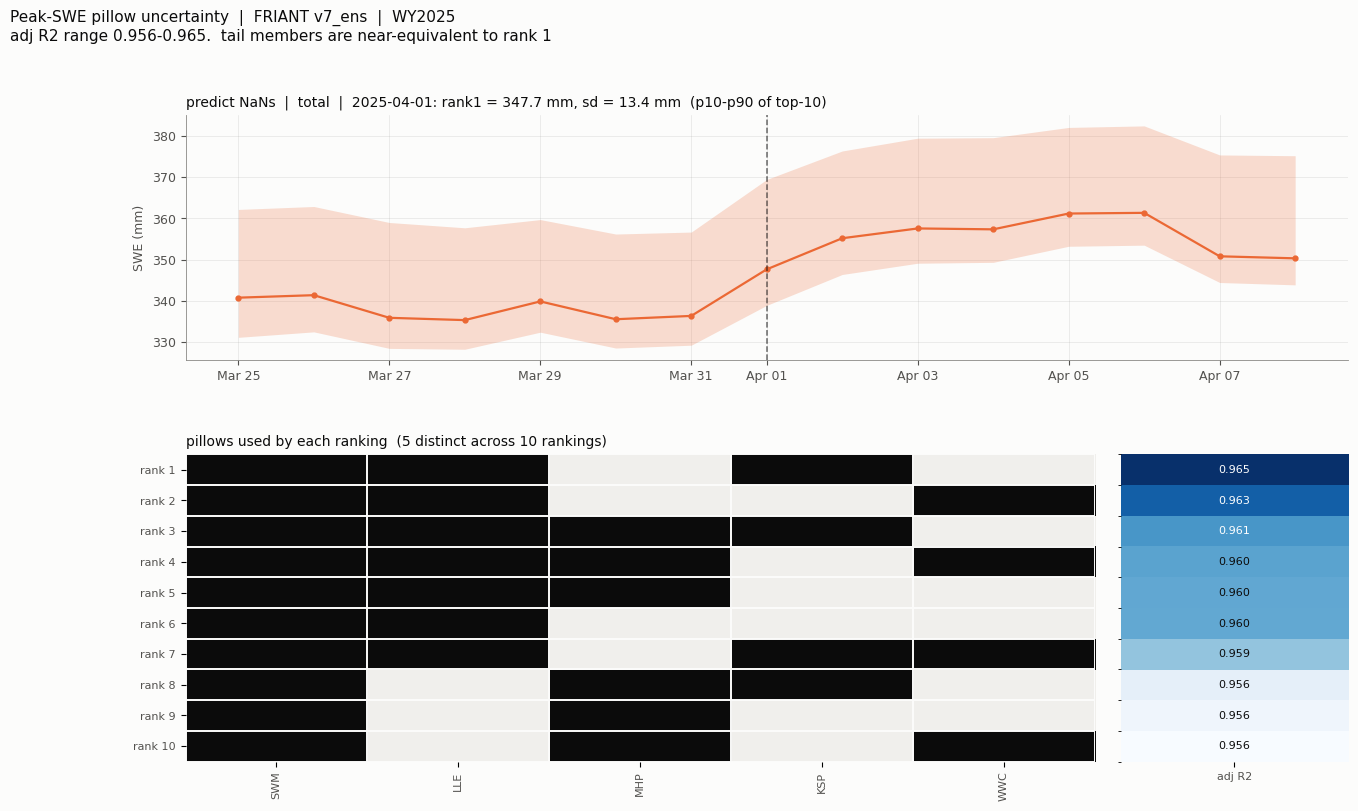

' rank  adj_r2         pillows  pred_mm\n    1   0.965     KSP,LLE,SWM  347.657\n    2   0.963     LLE,SWM,WWC  330.749\n    3   0.961 KSP,LLE,MHP,SWM  356.771\n    4   0.960 LLE,MHP,SWM,WWC  344.482\n    5   0.960     LLE,MHP,SWM  359.575\n    6   0.960         LLE,SWM  344.942\n    7   0.959 KSP,LLE,SWM,WWC  339.835\n    8   0.956     KSP,MHP,SWM  368.860\n    9   0.956         MHP,SWM  374.664\n   10   0.956     MHP,SWM,WWC  356.217'

In [10]:
ZOOM_DAYS = 7   # window is DATE +/- this many days

d0 = pd.Timestamp(DATE)
lo_d, hi_d = d0 - pd.Timedelta(days=ZOOM_DAYS), d0 + pd.Timedelta(days=ZOOM_DAYS)

# members for the single selected date / mode / elevation band
sel = e[(e.isImpute == MODE_FLAG[MODEL]) & (e.elev_band == ELEV_BAND) &
        (e.water_year == WATER_YEAR) & (e.date.dt.normalize() == d0)]
sel = sel[sel['rank'] <= N_RANKS].sort_values('rank')
if sel.empty:
    raise SystemExit(f'no members for {DATE} / {MODEL} / {ELEV_BAND} / WY{WATER_YEAR}')

# pillow x rank occupancy. Column order follows how often a pillow appears, so the
# most-relied-on stations sit on the left rather than in alphabetical accident.
per_rank = {int(r['rank']): [p for p in str(r['pillows']).split(',') if p] for _, r in sel.iterrows()}
counts = pd.Series([p for v in per_rank.values() for p in v]).value_counts()
pillows_x = list(counts.index)
ranks_y = sorted(per_rank)
occ = np.array([[1 if p in per_rank[rk] else 0 for p in pillows_x] for rk in ranks_y])
r2_col = sel.set_index('rank').loc[ranks_y, 'adj_r2'].astype(float).values

zoom = ensemble_band(MODEL, ELEV_BAND, WATER_YEAR)
zoom = zoom[(zoom.index >= lo_d) & (zoom.index <= hi_d)]

fig = plt.figure(figsize=(15, 8.4), facecolor=SURFACE)
gs = fig.add_gridspec(2, 2, height_ratios=[1.0, 1.25],
                      width_ratios=[max(len(pillows_x), 6), 1.5],
                      hspace=0.34, wspace=0.045)
ax_ts = fig.add_subplot(gs[0, :])
ax_hm = fig.add_subplot(gs[1, 0])
ax_r2 = fig.add_subplot(gs[1, 1], sharey=ax_hm)

# ---- subplot 1: the zoomed series ----
ax_ts.set_facecolor(SURFACE)
for s in ('top', 'right'):
    ax_ts.spines[s].set_visible(False)
for s in ('left', 'bottom'):
    ax_ts.spines[s].set_color(MUTED); ax_ts.spines[s].set_linewidth(0.6)
ax_ts.grid(True, color=MUTED, alpha=0.20, linewidth=0.5); ax_ts.set_axisbelow(True)
ax_ts.tick_params(colors=INK2, labelsize=9)
C = MODE_COLORS[MODEL]
ax_ts.fill_between(zoom.index, zoom.lo, zoom.hi, color=C, alpha=0.22, lw=0, zorder=2)
ax_ts.plot(zoom.index, zoom.rank1, color=C, lw=1.6, marker='o', ms=3.5, zorder=3)
ax_ts.axvline(d0, color=INK, lw=1.1, ls='--', alpha=0.6, zorder=4)
ax_ts.set_ylabel('SWE (mm)', fontsize=9, color=INK2)
ax_ts.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
sd_here = float(zoom.sd.reindex([d0]).iloc[0]) if d0 in zoom.index else float('nan')
r1_here = float(zoom.rank1.reindex([d0]).iloc[0]) if d0 in zoom.index else float('nan')
ax_ts.set_title(f'{MODEL}  |  {ELEV_BAND}  |  {DATE}: rank1 = {r1_here:.1f} mm, '
                f'sd = {sd_here:.1f} mm  ({band_label})',
                fontsize=10, color=INK, loc='left', pad=6)

# ---- subplot 2: which pillows each ranking used ----
# Binary presence/absence, so two flat tones rather than a ramp -- there is no magnitude here.
from matplotlib.colors import ListedColormap
ax_hm.imshow(occ, cmap=ListedColormap(['#f0efec', '#0b0b0b']), aspect='auto',
             vmin=0, vmax=1, interpolation='nearest')
ax_hm.set_xticks(range(len(pillows_x)))
ax_hm.set_xticklabels(pillows_x, rotation=90, fontsize=8, color=INK2)
ax_hm.set_yticks(range(len(ranks_y)))
ax_hm.set_yticklabels([f'rank {r}' for r in ranks_y], fontsize=8, color=INK2)
ax_hm.set_xticks(np.arange(-.5, len(pillows_x), 1), minor=True)
ax_hm.set_yticks(np.arange(-.5, len(ranks_y), 1), minor=True)
ax_hm.grid(which='minor', color=SURFACE, linewidth=1.4)
ax_hm.tick_params(which='minor', length=0)
for s in ax_hm.spines.values():
    s.set_visible(False)
ax_hm.set_title(f'pillows used by each ranking  ({len(pillows_x)} distinct across '
                f'{len(ranks_y)} rankings)', fontsize=10, color=INK, loc='left', pad=6)

# ---- adj_r2 strip, offset to the right ----
# This IS a magnitude, so one hue light->dark rather than the binary tones on the left.
ax_r2.imshow(r2_col.reshape(-1, 1), cmap='Blues', aspect='auto',
             vmin=np.nanmin(r2_col), vmax=np.nanmax(r2_col), interpolation='nearest')
for i, v in enumerate(r2_col):
    rel = (v - np.nanmin(r2_col)) / max(np.nanmax(r2_col) - np.nanmin(r2_col), 1e-12)
    ax_r2.text(0, i, f'{v:.3f}', ha='center', va='center', fontsize=8,
               color='#ffffff' if rel > 0.55 else INK)
ax_r2.set_xticks([0]); ax_r2.set_xticklabels(['adj R2'], fontsize=8, color=INK2)
ax_r2.tick_params(axis='y', length=0, labelleft=False)
for s in ax_r2.spines.values():
    s.set_visible(False)

drop = float(np.nanmax(r2_col) - np.nanmin(r2_col))
note = ('  tail members are near-equivalent to rank 1'
        if drop < 0.05 else
        f'  WARNING: adj R2 falls {drop:.3f} from rank 1 to rank {ranks_y[-1]} -- the tail '
        'members are models the selection criterion rejected, so an unweighted band overstates '
        'uncertainty here')
fig.suptitle(f'Peak-SWE pillow uncertainty  |  {BASIN} {VERSION}  |  WY{WATER_YEAR}\n'
             f'adj R2 range {np.nanmin(r2_col):.3f}-{np.nanmax(r2_col):.3f}.{note}',
             x=0.008, ha='left', y=1.005, fontsize=11, color=INK)
fig.tight_layout(rect=[0.006, 0, 1, 0.93])
plt.show()

display(sel[['rank', 'adj_r2', 'pillows', 'pred_mm']].round(3).to_string(index=False))

## Does spread depend on pillow availability?

This is the question the ensemble was built to answer, and it needs care. Relative spread
(`sd` as a percent of rank 1) explodes whenever rank 1 is near zero, so early-season dates
with no snow will dominate any percentage-based comparison and look like huge uncertainty.
Below, absolute spread in mm is reported alongside, and low-SWE dates are excluded.

In [6]:
MIN_SWE_MM = 50   # exclude near-zero dates: a percentage of ~0 is not an uncertainty signal

a = agg[agg.rank1 >= MIN_SWE_MM].copy()
a['sd_pct'] = 100 * a.sd / a.rank1

if 'n_QA' in a.columns:
    by = a.groupby('n_QA').agg(dates=('sd', 'size'), mean_rank1_mm=('rank1', 'mean'),
                               mean_sd_mm=('sd', 'mean'), median_sd_pct=('sd_pct', 'median'))
    print(f'spread vs available pillows (dates with rank1 >= {MIN_SWE_MM} mm)')
    display(by.round(1))
    if len(by) > 1:
        r = a[['n_QA', 'sd']].corr().iloc[0, 1]
        rp = a[['n_QA', 'sd_pct']].corr().iloc[0, 1]
        print(f'corr(n_QA, absolute sd) = {r:+.3f}   corr(n_QA, sd %) = {rp:+.3f}')
    else:
        print('only one n_QA value present -- needs more water years to be informative')
else:
    print('n_QA not in this file (predates the column); rerun the sweep to populate it')

print()
print('spread by decade')
dec = a.assign(decade=(a.index.year // 10) * 10).groupby('decade').agg(
    dates=('sd', 'size'), mean_rank1_mm=('rank1', 'mean'),
    mean_sd_mm=('sd', 'mean'), median_sd_pct=('sd_pct', 'median'))
display(dec.round(1))

spread vs available pillows (dates with rank1 >= 50 mm)


,dates,mean_rank1_mm,mean_sd_mm,median_sd_pct
n_QA,,,,
3,10,123.0,7.9,7.8
4,19,204.4,43.3,17.4
5,88,411.4,38.9,10.5
6,63,419.6,104.2,27.4
8,21,172.3,35.9,20.8
9,455,266.8,26.0,8.3
10,347,379.8,46.1,10.8
11,388,286.8,46.6,15.8
12,304,217.0,32.0,13.2


corr(n_QA, absolute sd) = -0.155   corr(n_QA, sd %) = -0.104

spread by decade


,dates,mean_rank1_mm,mean_sd_mm,median_sd_pct
decade,,,,
1970,7,91.6,16.0,19.6
1980,1554,307.6,42.3,13.3
1990,1937,268.9,27.7,8.3
2000,1338,287.9,34.5,11.0
